# Where should the National Park Service spend its DC campaign budget?

**Analyst:** Maurice Colbert Jr. · **Stack:** Python, pandas, matplotlib

## The brief

The National Park Service was planning a promotional campaign for its Washington, DC
sites and needed the 2024 visitation data checked and interpreted first. The practical
questions were **where** to promote and **when** to promote it.

## How I approached it

A campaign has two levers, so I built the analysis around them rather than around the
data files:

- **Targeting** — is attention spread across the DC sites or concentrated in a few?
  That decides whether the campaign should amplify the popular sites or redirect
  demand toward the quiet ones.
- **Timing** — is demand seasonal, and if so, is the campaign better spent filling
  quiet months or reinforcing busy ones?

One thing I decided before starting: this dataset is small enough (23 sites, 12
months) that the analytical risk is not computation, it is accepting a wrong number.
So I validated the extremes instead of only summarizing the middle.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

GREEN = "#2d6a4f"
CLAY = "#bc6c25"

sites = pd.read_csv("data/national_parks_recreation_visits.csv")
monthly = pd.read_csv("data/monthly_dc_visitors.csv")

print(f"Sites: {len(sites)} | 2024 recreation visits: {sites.RecreationVisits.sum():,}")
sites.sort_values("RecreationVisits", ascending=False).head()

Sites: 23 | 2024 recreation visits: 41,300,210


,ParkName,RecreationVisits
8,Lincoln MEM,8479349
17,Vietnam Veterans MEM,5295711
22,World War II MEM,5160769
6,Korean War Veterans MEM,4344305
9,"Martin Luther King, Jr. MEM",3251594


## Targeting: attention is extremely concentrated

The first question is whether "the DC parks" behave like one audience or like a few
famous landmarks plus a long tail. I measured concentration rather than eyeballing the
ranking.

In [2]:
ranked = sites.sort_values("RecreationVisits", ascending=False).reset_index(drop=True)
total = ranked.RecreationVisits.sum()
ranked["pct_of_total"] = (100 * ranked.RecreationVisits / total).round(2)
ranked["cumulative_pct"] = ranked.pct_of_total.cumsum().round(1)

print(f"Lincoln Memorial alone:      {ranked.pct_of_total[0]:.1f}% of all DC recreation visits")
print(f"Top 5 sites combined:        {ranked.cumulative_pct[4]:.1f}%")
print(f"Bottom 10 sites combined:    {100 - ranked.cumulative_pct[12]:.1f}%")
ranked.head(8)

Lincoln Memorial alone:      20.5% of all DC recreation visits
Top 5 sites combined:        64.2%
Bottom 10 sites combined:    4.0%


,ParkName,RecreationVisits,pct_of_total,cumulative_pct
0,Lincoln MEM,8479349,20.53,20.5
1,Vietnam Veterans MEM,5295711,12.82,33.4
2,World War II MEM,5160769,12.50,45.8
3,Korean War Veterans MEM,4344305,10.52,56.4
4,"Martin Luther King, Jr. MEM",3251594,7.87,64.2
5,Franklin Delano Roosevelt MEM,3225923,7.81,72.1
6,Thomas Jefferson MEM,2915319,7.06,79.1
7,Rock Creek Park,1917170,4.64,83.8


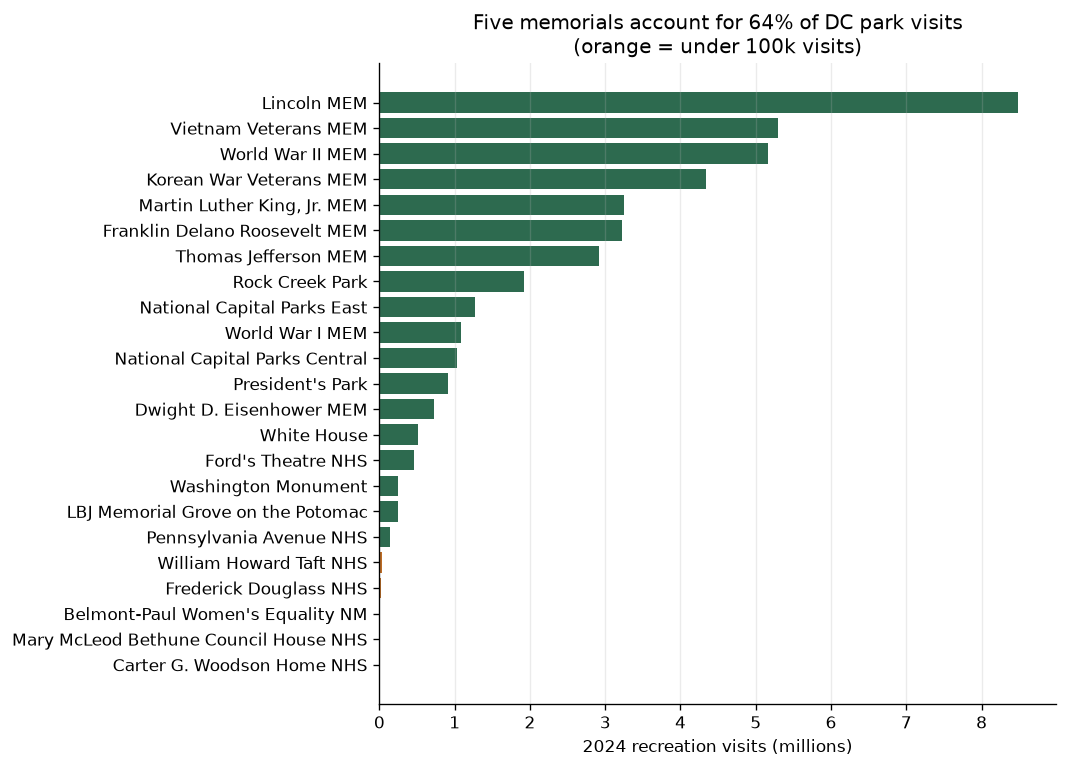

In [3]:
fig, ax = plt.subplots(figsize=(9, 6.5))
plot_df = ranked.sort_values("RecreationVisits")
colors = [CLAY if v < 100_000 else GREEN for v in plot_df.RecreationVisits]
ax.barh(plot_df.ParkName, plot_df.RecreationVisits / 1_000_000, color=colors)
ax.set_xlabel("2024 recreation visits (millions)")
ax.set_title("Five memorials account for 64% of DC park visits\n(orange = under 100k visits)")
ax.grid(axis="y", visible=False)
ax.margins(x=0.06)
fig.tight_layout()
fig.savefig(FIGURES / "01_visits_by_site.png", bbox_inches="tight")
plt.show()

The distribution is steep: the Lincoln Memorial takes 20.5% of all visits on its own,
the top five sites take 64.2%, and the bottom ten share 4.0% between them. The DC
parks are not one audience — they are a handful of monuments on every tourist itinerary
plus a set of historic sites almost nobody is routed to.

### Validating the extremes before reporting them

The bottom of the ranking is where I expected a data problem, and there was one.

In [4]:
ranked.tail(5)[["ParkName", "RecreationVisits", "pct_of_total"]]

,ParkName,RecreationVisits,pct_of_total
18,William Howard Taft NHS,31118,0.08
19,Frederick Douglass NHS,25836,0.06
20,Belmont-Paul Women's Equality NM,7704,0.02
21,Mary McLeod Bethune Council House NHS,3338,0.01
22,Carter G. Woodson Home NHS,30,0.00


**The Carter G. Woodson Home reports 30 recreation visits for the entire year.** That
is not a small number, it is an implausible one — roughly one visitor every twelve
days at a site in a dense neighbourhood of a major city.

I could not resolve it from this dataset alone, so I am reporting it as a data-quality
flag rather than as a finding: the site was most likely closed for part or all of 2024,
or its visits are being counted under `National Capital Parks East`. Averaging it into
a "least visited sites" recommendation without saying so would have handed the client a
conclusion built on a broken counter.

Mary McLeod Bethune Council House (3,338) and Belmont-Paul Women's Equality (7,704) are
low but plausible, so those I do treat as real.

## Timing: two demand patterns, not one

In [5]:
monthly["month_name"] = monthly.Month.apply(lambda n: pd.Timestamp(2024, n, 1).strftime("%b"))
seasonality = monthly[["month_name", "RecreationVisits", "NonRecreationVisits"]].set_index("month_name")

peak = monthly.loc[monthly.RecreationVisits.idxmax()]
trough = monthly.loc[monthly.RecreationVisits.idxmin()]
print(f"Busiest month: {peak.month_name} — {peak.RecreationVisits:,} recreation visits")
print(f"Quietest month: {trough.month_name} — {trough.RecreationVisits:,}")
print(f"Peak-to-trough ratio: {peak.RecreationVisits / trough.RecreationVisits:.2f}x")
print(f"March–October share of the year: "
      f"{100 * monthly[monthly.Month.between(3, 10)].RecreationVisits.sum() / monthly.RecreationVisits.sum():.1f}%")

Busiest month: Mar — 5,243,194 recreation visits
Quietest month: Jan — 1,476,620
Peak-to-trough ratio: 3.55x
March–October share of the year: 79.9%


I then compared recreation visits against non-recreation visits. The second column is
easy to ignore, but it is what separates campaign-addressable demand from traffic that
will arrive regardless.

In [6]:
volatility = pd.DataFrame({
    "total_visits": [monthly.RecreationVisits.sum(), monthly.NonRecreationVisits.sum()],
    "monthly_min": [monthly.RecreationVisits.min(), monthly.NonRecreationVisits.min()],
    "monthly_max": [monthly.RecreationVisits.max(), monthly.NonRecreationVisits.max()],
    "coeff_of_variation": [
        round(monthly.RecreationVisits.std() / monthly.RecreationVisits.mean(), 3),
        round(monthly.NonRecreationVisits.std() / monthly.NonRecreationVisits.mean(), 3),
    ],
}, index=["Recreation", "Non-recreation"])
volatility

,total_visits,monthly_min,monthly_max,coeff_of_variation
Recreation,41300210,1476620,5243194,0.350
Non-recreation,45376923,3381324,3984653,0.045


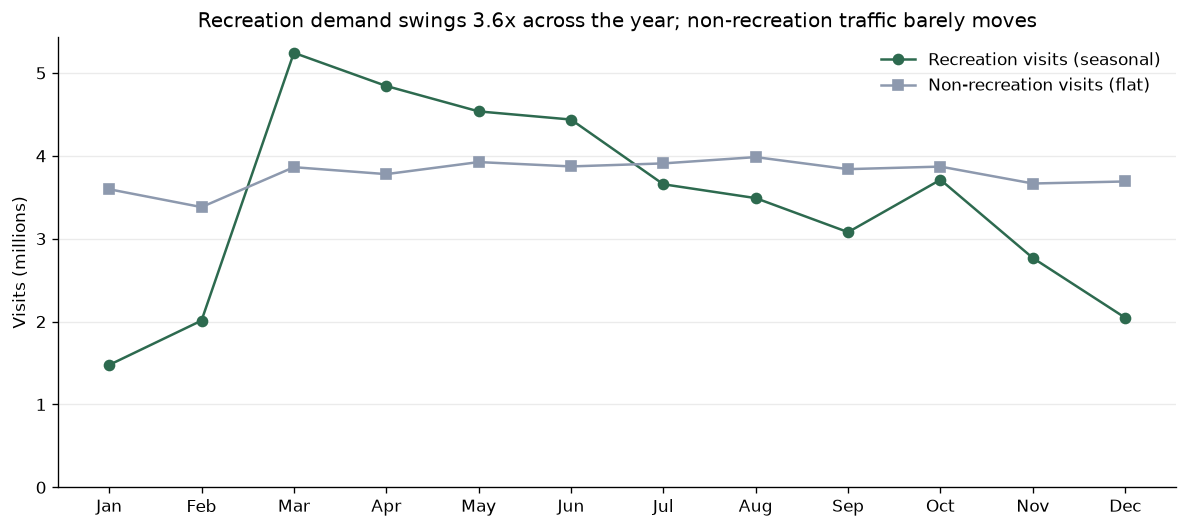

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(seasonality.index, seasonality.RecreationVisits / 1_000_000,
        marker="o", color=GREEN, label="Recreation visits (seasonal)")
ax.plot(seasonality.index, seasonality.NonRecreationVisits / 1_000_000,
        marker="s", color="#8d99ae", label="Non-recreation visits (flat)")
ax.set_ylabel("Visits (millions)")
ax.set_title("Recreation demand swings 3.6x across the year; non-recreation traffic barely moves")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
ax.set_ylim(0, None)
fig.tight_layout()
fig.savefig(FIGURES / "02_seasonality.png", bbox_inches="tight")
plt.show()

The coefficient of variation makes the contrast precise: recreation visits vary at
0.350, non-recreation at 0.045. Recreation demand is strongly seasonal, peaking in
March (cherry blossom season, 5.24M visits) and bottoming in January (1.48M) — a 3.6x
swing. Non-recreation traffic sits between 3.4M and 4.0M every month regardless of
weather or season.

That means the 45.4M non-recreation visits are commuters and through-traffic, not an
audience a promotional campaign can move. **The campaign's addressable market is the
41.3M recreation visits, and 79.9% of those already happen between March and October.**

In [8]:
# How long does a visit actually last? Hours per visit sets expectations for
# any "spend more time here" campaign message.
hours_per_visit = monthly.RecreationHours.sum() / monthly.RecreationVisits.sum()
print(f"Average recreation hours per visit: {hours_per_visit:.2f} ({hours_per_visit * 60:.0f} minutes)")

Average recreation hours per visit: 0.61 (37 minutes)


Thirty-seven minutes per visit confirms the behaviour these numbers describe: DC park
visits are short monument stops on a walking route, not day trips. A campaign asking
people to spend an afternoon at one site is fighting the observed pattern; a campaign
adding one more short stop to an existing route is working with it.

## Recommendations

1. **Promote the quiet sites using the busy ones as the entry point.** Concentration
   is the opportunity, not the problem: the Lincoln Memorial's 8.5M visitors are
   already within walking distance of sites drawing under 30k. Cross-promotion at the
   high-traffic memorials will move more people than standalone advertising for a site
   nobody is searching for.
2. **Run the campaign in the shoulder months — April–June and September–October.**
   March is already at capacity from cherry blossom season, and January–February
   demand is weather-limited in ways marketing cannot fix. The shoulder months have
   good conditions and unmet capacity.
3. **Design for a 37-minute visit.** Short routes that chain two or three nearby sites
   fit how people actually use these parks.
4. **Do not report the Carter G. Woodson Home figure without verification.** Thirty
   visits in a year almost certainly reflects a closure or a counting change, and it
   would be the wrong basis for a targeting decision.

## Limitations

- One year of data, so I cannot separate a 2024-specific pattern from a stable one.
  March's spike is consistent with cherry blossom timing, which moves year to year.
- The site-level and monthly files cannot be joined: monthly totals are DC-wide, so I
  cannot tell whether individual sites peak in different months.
- Recreation vs non-recreation is the Park Service's own classification, and the
  overnight and camping columns are entirely zero for these urban sites.

## How I used AI on this project

I did the analysis and wrote the recommendations. AI was a copilot for two mechanical
things: converting month numbers to names, and confirming the pandas syntax for a
grouped bar chart. Both are formatting details, not analysis. The interpretation of the
concentration and seasonality patterns, and the decision to flag rather than report the
30-visit record, are my own.